Task1
---

In [79]:
def BFS(start, graph):
    queue = []
    visited = set()

    queue.append(start)
    visited.add(start)

    while queue:
        node = queue.pop(0)
        print(node, end=" ")

        for neighbor in graph[node]:
            if neighbor not in visited:
                queue.append(neighbor)
                visited.add(neighbor)

In [80]:
def DFS(graph, start):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()   # LIFO (stack)
        print(node,end=" ")
        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                stack.append(neighbor)

    

In [81]:
graph = {
    1 : [2,3],
    2 : [4,5],
    3 : [6,7],
    4 : [],
    5 : [],
    6 : [],
    7 : []
}

BFS(1,graph)
print("\n")
DFS(graph,1)

1 2 3 4 5 6 7 

1 3 7 6 2 5 4 

Task2
---

      Size  BFS Time  DFS Time
0     1000  0.001151  0.000311
1    40000  0.024096  0.013512
2    80000  0.050706  0.029418
3   200000  0.129818  0.035468
4  1000000  0.952204  0.045742


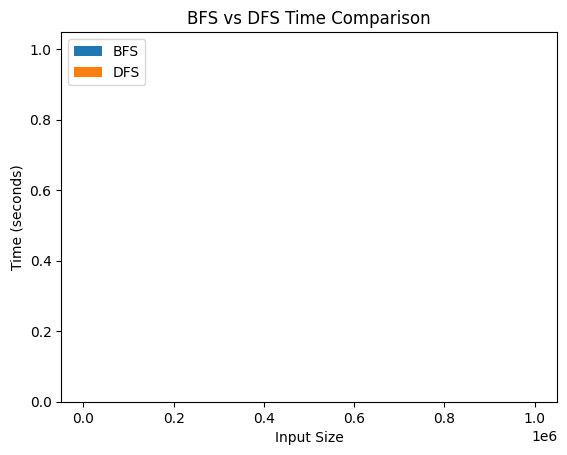

In [77]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# Step 1: Generate datasets
sizes = [1000, 40000, 80000, 200000, 1000000]
datasets = {}

for size in sizes:
    datasets[size] = random.sample(range(size * 10), size)  # unique numbers

# Step 2: Build a simple graph (tree-like)
def build_graph(lst):
    graph = {}
    for i in range(len(lst)):
        graph[lst[i]] = []
        left = 2*i + 1
        right = 2*i + 2
        if left < len(lst):
            graph[lst[i]].append(lst[left])
        if right < len(lst):
            graph[lst[i]].append(lst[right])
    return graph

# BFS
def BFS(graph, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])
    return False

# DFS
def DFS(graph, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()
        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])
    return False

# Step 3 & 4: Measure time and store results
results = []

for size in sizes:
    lst = datasets[size]
    graph = build_graph(lst)

    start = lst[0]
    goal = lst[len(lst) - 220]

    # BFS Time
    start_time = time.time()
    BFS(graph, start, goal)
    bfs_time = time.time() - start_time

    # DFS Time
    start_time = time.time()
    DFS(graph, start, goal)
    dfs_time = time.time() - start_time

    results.append([size, bfs_time, dfs_time])

# Create DataFrame
df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
print(df)

# Step 5: Plot Bar Chart
plt.figure()
x = df["Size"]

plt.bar(x, df["BFS Time"], label="BFS")
plt.bar(x, df["DFS Time"], bottom=df["BFS Time"], label="DFS")

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Time Comparison")
plt.legend()

plt.show()

TASK3
---

In [52]:
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

In [64]:
from collections import deque

def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])   # queue stores paths

    visited = set()

    while queue:
        path = queue.popleft()   # get first path
        node = path[-1]          # last node in path

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = path + [neighbor]
                queue.append(new_path)

    return None


In [65]:
bfs_shortest_path(graph,"Islamabad","Karachi")

['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']